[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/computational-chemical-biology/AdvancesMSDataProcessing/blob/master/SupervisedUnsupervisedMachineLearning/dreams_beer_profiler_workshop.ipynb)


> **Source:** [github.com](https://github.com/pluskal-lab/DreaMS)


# 🍻 DreaMS beer profiler (EuBIC-MS 2026 workshop)

![DreaMS logo](https://github.com/pluskal-lab/DreaMS/blob/main/assets/dreams_background.png?raw=true)

## 1. Copy this notebook to your Google Drive

<img src="https://raw.githubusercontent.com/pluskal-lab/DreaMS/main/assets/workshop_eubicms2026/workshop_guide0.png" width="300">

## 2. Configure Google Colab

### Select Google Colab runtime

Please go to '▼' → 'Change runtime type' in the top right corner.

<img src="https://raw.githubusercontent.com/pluskal-lab/DreaMS/main/assets/workshop_eubicms2026/workshop_guide1.png" width="300">

Please configure the runtime as shown in the picture. Select 'Python 3', 'T4 GPU', and '2025.07'.

<img src="https://github.com/pluskal-lab/DreaMS/blob/main/assets/workshop_eubicms2026/workshop_guide2.png?raw=true" width="400">

## 3. Install DreaMS and download tutorial data

Run the cell below to set up DreaMS and download the workshop assets (model checkpoints + data).

<img src="https://github.com/pluskal-lab/DreaMS/blob/main/assets/workshop_eubicms2026/workshop_guide3.png?raw=true" width="200">

After around 10-15 minutes the cell output will show the following lines.

```bash
🔔 The installation of DreaMS is complete. Now restart the runtime: 'Runtime' → 'Restart session and run all'
```

Please follow the instruction and restart the session. The `Runtime` button is located in the top panel under the file name. Click `Yes` if you are asked `Are you sure...?`.


In [ ]:
#@title Run installation (10-15 min)

# PLEASE IGNORE THE CODE IN THIS CELL. IT IS INTENDED SOLELY FOR INSTALLING DREAMS
# AND PREPARING THE NECCESSARY DATA, NOT FOR TUTORIAL PURPOSES.

# DreaMS workshop setup (Colab-friendly, idempotent, shows pip output)
import os
import sys
import shutil
import importlib.util
import hashlib
import warnings
from pathlib import Path

REPO_URL = "https://github.com/pluskal-lab/DreaMS.git"
REPO_DIR = Path("DreaMS")

HF_REPO_ID = "roman-bushuiev/DreaMS"
CHECKPOINTS = ["ssl_model.ckpt", "embedding_model.ckpt"]

GEMS_DATASET_REPO = "roman-bushuiev/GeMS"  # HF dataset repo
GEMS_WORKSHOP_FOLDER = "data/auxiliary/workshop_eubicms2026/"
GEMS_HDF5_FILE = "data/auxiliary/MassSpecGym_DreaMS.hdf5"

# Download everything into THIS folder (relative to /content)
DATA_DIR = Path("data")

def is_importable(name: str) -> bool:
    return importlib.util.find_spec(name) is not None

def sh(cmd: str):
    # Jupyter/Colab-friendly command runner: output always shows
    print("+", cmd)
    get_ipython().system(cmd)

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def copy_if_missing_or_size_mismatch(src: Path, dst: Path):
    """
    Copies src -> dst if dst missing or has different size.
    """
    ensure_dir(dst.parent)
    if dst.exists() and dst.stat().st_size == src.stat().st_size:
        return False  # unchanged
    if dst.exists():
        dst.unlink()
    shutil.copy2(src, dst)
    return True

def short_hash(s: str, n: int = 8) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()[:n]

# --- 0) Basic info ---
print("Python:", sys.version.split()[0])
print("Working dir:", Path.cwd())

# --- 1) Clone repo if missing ---
if not REPO_DIR.exists():
    sh(f"git clone {REPO_URL} {REPO_DIR}")
else:
    print(f"Repo already present at {REPO_DIR.resolve()} (skipping clone)")

# --- 2) Editable install if needed ---
# Important: don't import dreams before this; Colab may require a restart after installs.
if not is_importable("dreams"):
    print("\nInstalling DreaMS...\n")
    sh('python -m pip install -e DreaMS')
    sh('python -m pip install dash==2.17.1')

    print("DreaMS package installation is finished")
    print("\n🔔 The installation of DreaMS is complete. Now restart the runtime: 'Runtime' → 'Restart session and run all'\n")

    # This prevents IPython from showing the traceback for SystemExit
    warnings.filterwarnings("ignore", category=UserWarning, module="IPython.core.interactiveshell")
    get_ipython().showtraceback = lambda *args, **kwargs: None
    sys.exit(0)
else:
    print("Package 'dreams' is importable (skipping pip install)")

# --- 3) Download pretrained weights (HF cache + link/copy into DreaMS folder) ---
if not is_importable("huggingface_hub"):
    print("\nInstalling huggingface_hub...\n")
    sh("python -m pip install -q huggingface_hub")

from huggingface_hub import hf_hub_download, snapshot_download

from dreams.definitions import PRETRAINED
TARGET_DIR = Path(PRETRAINED)
ensure_dir(TARGET_DIR)
print("Pretrained dir:", TARGET_DIR.resolve())

for ckpt in CHECKPOINTS:
    cached_path = Path(hf_hub_download(repo_id=HF_REPO_ID, filename=ckpt))
    target_path = TARGET_DIR / ckpt

    # Validate existing target
    if target_path.exists():
        if target_path.is_symlink():
            print(f"{ckpt}: valid symlink, keeping")
            continue
        if target_path.stat().st_size == cached_path.stat().st_size:
            print(f"{ckpt}: valid file, keeping")
            continue
        print(f"{ckpt}: size mismatch, deleting corrupted/partial file")
        target_path.unlink()

    # Create link (fast) or copy (fallback)
    try:
        target_path.symlink_to(cached_path)
        print(f"{ckpt}: symlinked")
    except OSError:
        shutil.copy2(cached_path, target_path)
        print(f"{ckpt}: copied (symlink not supported)")

# --- 4) Download workshop data into flat ./data ---
ensure_dir(DATA_DIR)
print("Data dir:", DATA_DIR.resolve())

print("\nDownloading GeMS workshop folder from Hugging Face...\n")
cache_root = Path(snapshot_download(
    repo_id=GEMS_DATASET_REPO,
    repo_type="dataset",
    allow_patterns=[f"{GEMS_WORKSHOP_FOLDER}**", GEMS_HDF5_FILE],
))

src_folder = cache_root / GEMS_WORKSHOP_FOLDER
if not src_folder.exists():
    raise FileNotFoundError(
        f"Could not find {GEMS_WORKSHOP_FOLDER} inside snapshot: {cache_root}"
    )

# Copy all files from the folder into DATA_DIR (flat).
# If basenames collide, prefix with a short hash of the original relative path.
copied = 0
kept = 0
collisions = 0
seen_names = set()

for src_file in sorted(src_folder.rglob("*")):
    if not src_file.is_file():
        continue

    rel = src_file.relative_to(src_folder).as_posix()
    base = src_file.name

    dst_name = base
    if dst_name in seen_names and not (DATA_DIR / dst_name).exists():
        # (rare) same name encountered earlier but target wasn't created; still treat as collision
        pass

    if (DATA_DIR / dst_name).exists() and (DATA_DIR / dst_name).stat().st_size == src_file.stat().st_size:
        # Already have same-name same-size file
        kept += 1
        seen_names.add(dst_name)
        continue

    if (DATA_DIR / dst_name).exists() and (DATA_DIR / dst_name).stat().st_size != src_file.stat().st_size:
        # Collision with different content/size -> disambiguate filename
        collisions += 1
        dst_name = f"{short_hash(rel)}__{base}"

    dst_path = DATA_DIR / dst_name
    if copy_if_missing_or_size_mismatch(src_file, dst_path):
        copied += 1
    else:
        kept += 1
    seen_names.add(dst_name)

print(f"Workshop folder: {copied} copied/updated, {kept} already OK, {collisions} name-collisions handled")
print("Workshop data target (flat):", DATA_DIR.resolve())

print("\nDownloading MassSpecGym_DreaMS.hdf5 into ./data ...\n")
hdf5_cached = Path(hf_hub_download(
    repo_id=GEMS_DATASET_REPO,
    repo_type="dataset",
    filename=GEMS_HDF5_FILE,
))
hdf5_target = DATA_DIR / "MassSpecGym_DreaMS.hdf5"
changed = copy_if_missing_or_size_mismatch(hdf5_cached, hdf5_target)
print("HDF5 target:", hdf5_target.resolve(), "|", ("copied/updated" if changed else "already present"))

# --- 5) Test installation ---
print("Starting DreaMS embeddings computation test")
from dreams.api import dreams_embeddings
dreams_embeddings("DreaMS/data/examples/example_5_spectra.mgf")
print("\nInstallation test: OK")
print("\nSetup complete ✅")

Python: 3.11.13
Working dir: /content
Repo already present at /content/DreaMS (skipping clone)
Package 'dreams' is importable (skipping pip install)
Pretrained dir: /content/DreaMS/dreams/models/pretrained


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


ssl_model.ckpt: valid symlink, keeping
embedding_model.ckpt: valid symlink, keeping
Data dir: /content/data




Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Workshop folder: 0 copied/updated, 14 already OK, 0 name-collisions handled
Workshop data target (flat): /content/data


HDF5 target: /content/data/MassSpecGym_DreaMS.hdf5 | already present
Starting DreaMS embeddings computation test


Computing DreaMS embeddings: 100%|██████████| 5/5 [00:00<00:00, 96.24it/s]


Installation test: OK

Setup complete ✅


In [ ]:
#@title Import all necessary packages

import random
import molplotly
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
from dreams.utils.data import MSData
from dreams.algorithms.lsh import BatchedPeakListRandomProjection
from dreams.utils.dformats import assign_dformat
from dreams.utils.plots import init_plotting
from dreams.utils.mols import show_mols
from dreams.utils.spectra import unpad_peak_list
from dreams.definitions import DATA_DIR
from dreams.api import dreams_embeddings, DreaMSSearch

## 🍻 DreaMS beer profiler

In this workshop, we will build a [DreaMS](https://www.nature.com/articles/s41587-025-02663-3)-based chemical profiler for beer samples. We will compare beer chemical profiles and use them to infer the content of two mystery beers.

We will use data from the MassIVE dataset [MSV000084900](https://massive.ucsd.edu/ProteoSAFe/dataset.jsp?task=ce3254fe529d43f48077d7ad55b7da09) (Gauglitz et al.), which contains metabolite analyses of ~3500 food and beverage samples extracted with ethanol. Data were acquired on a Bruker Daltonics maXis Impact using C18 RP-UHPLC with LC-MS/MS in positive ion mode. Here, we focus on 12 beer samples and compare their chemical profiles using DreaMS.

<img src="https://raw.githubusercontent.com/pluskal-lab/DreaMS/main/assets/workshop_eubicms2026/beer_images.png" width="700">

High-level steps:
1. Extract and preprocess MS/MS spectra from LC-MS/MS experiment.
2. Compare beers by analyzing molecule embeddings (MS/MS spectrum embeddings).
3. Build a taxonomic tree of beers by analyzing beer embeddings (LC-MS/MS experiment embeddings).

💡 The same workflow can be applied to metabolic profiling of other samples (e.g., plant extracts). Treat this Colab notebook as an example tutorial.

### Load beers metadata

In [ ]:
data_dir = Path('data')
df = pd.read_csv(data_dir / 'metadata_beers.tsv', sep='\t')
df = df.set_index('filename')
print(f'Working with {len(df)} beer samples')
df['description']

Working with 12 beer samples


,description
filename,
75218_1x_BG8_01_20774.mzXML,gingerbeer
G73985_1x_10ul_RC5_01_18610.mzXML,alpirsbacher beer (5.2% alc/vol)
G74044_1x_RD3_01_18540.mzXML,Panic IPA Track Seven
G74050_1x_RG3_01_18581.mzXML,Koshihikari echigo beer
G74121_1x_RF9_01_18574.mzXML,warsteiner beer
G75744_1x_10ul_rerun_RF4_01_19934.mzXML,rootbeer
G75763_1x_RB9_01_18617.mzXML,berliner weisse beer
G75765_1x_RH7_01_18599.mzXML,warsteiner beer
G83430_1x_rerun_RE6_01_26502.mzXML,Stone Ruination Double IPA beer


### Load and process beer LC-MS/MS data

For each beer dataset (i.e., `.mzXML` file), we will perform four main steps:
1. Load the dataset
2. Cluster MS/MS spectra
3. Filter out low-quality MS/MS spectra
4. Compute a DreaMS embedding for each MS/MS spectrum

In [ ]:
# Define LSH clustering algorithm
lsh_projector = BatchedPeakListRandomProjection(bin_step=1, n_hyperplanes=25)

msdatasets = {}
embs = {}
for i, file_name in enumerate(df.index):
    print(f'[{i + 1} / {len(df)}]')

    # Load dataset
    f = data_dir / file_name

    # 1. Load .mzXML file and convert it to internal .hdf5 format
    msdata = MSData.load(f, in_mem=True)
    df_msdata = msdata.to_pandas()

    # 2. Compute LSH hashes (i.e., clusters of spectra)
    df_msdata['lsh'] = lsh_projector.compute(msdata.get_spectra(), progress_bar=False)

    # 3. Compute quality scores (see Fig. 2b in the paper https://www.nature.com/articles/s41587-025-02663-3/figures/2)
    df_msdata['dformat'] = [assign_dformat(unpad_peak_list(msdata.get_spectra()[i]), msdata.get_prec_mzs()[i]) for i in range(len(msdata))]

    # Filter data based on 2. and 3.
    df_msdata = df_msdata.drop_duplicates(subset=['lsh'])
    print('Num. spectra after LSH clustering:', len(df_msdata))
    df_msdata = df_msdata[df_msdata['dformat'] == 'A']
    print('Num. spectra after filtering:', len(df_msdata))

    # Save filtered spectra
    msdata = msdata.form_subset(idx=df_msdata.index.to_list(), out_pth=f.with_suffix('.filtered.hdf5'), mode='a')

    # 4. Compute DreaMS embeddings
    embs[file_name] = dreams_embeddings(msdata, store_embs=True)

    msdatasets[file_name] = msdata

embs_all = np.concatenate(list(embs.values()))
filenames_all = [k for k, v in embs.items() for _ in range(v.shape[0])]
print('Shape of all embeddings:', embs_all.shape)
print('Length of associated file names:', len(filenames_all))

[1 / 12]
Loading dataset 75218_1x_BG8_01_20774 into memory (1584 spectra)...
Num. spectra after LSH clustering: 969
Num. spectra after filtering: 97


Computing DreaMS embeddings: 100%|██████████| 97/97 [00:00<00:00, 154.49it/s]


[2 / 12]
Loading dataset G73985_1x_10ul_RC5_01_18610 into memory (2209 spectra)...
Num. spectra after LSH clustering: 1621
Num. spectra after filtering: 248


Computing DreaMS embeddings: 100%|██████████| 248/248 [00:01<00:00, 138.31it/s]


[3 / 12]
Loading dataset G74044_1x_RD3_01_18540 into memory (2342 spectra)...
Num. spectra after LSH clustering: 1747
Num. spectra after filtering: 383


...

[11 / 12]
Loading dataset G87518_1x_RF8_01_26447 into memory (1961 spectra)...
Num. spectra after LSH clustering: 1514
Num. spectra after filtering: 264


Computing DreaMS embeddings: 100%|██████████| 264/264 [00:01<00:00, 133.21it/s]


[12 / 12]
Loading dataset G87519_1x_RG8_01_26461 into memory (2007 spectra)...
Num. spectra after LSH clustering: 1512
Num. spectra after filtering: 296


Computing DreaMS embeddings: 100%|██████████| 296/296 [00:02<00:00, 133.89it/s]

Shape of all embeddings: (3403, 1024)
Length of associated file names: 3403


### Visualize DreaMS embeddings

Let's visualize the computed 1024-dimensional DreaMS embeddings in 2D using UMAP.

✨ Exercise:
- Compare `rootbeer` against `berliner weisse beer`.
- Look for regions of embedding space that are clearly sample-specific versus regions that are shared across multiple beers.

💡 Hint: double-click the legend to deselect all beers.


In [ ]:
# Initialize UMAP algorithm
random.seed(1)
reducer = umap.UMAP(metric='cosine', min_dist=0.5, n_neighbors=50, random_state=37)

# Transform 1024-d DreaMS embeddings into 2-d points
embs_umap = reducer.fit_transform(embs_all)

# Plot the UMAP
fig = px.scatter(
    x=embs_umap[:, 0],
    y=embs_umap[:, 1],
    color=df.loc[filenames_all, 'description'],
    hover_name=df.loc[filenames_all, 'description'],
    width=900,
    height=650,
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(xaxis_title=None, yaxis_title=None)
fig

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


### Annotate spectra with molecules by DreaMS library matching

We next run embedding-based library matching against [MassSpecGym](https://huggingface.co/datasets/roman-bushuiev/MassSpecGym) spectral library. This produces tentative compound annotations for a subset of spectra for which similar spectra are present in MassSpecGym.

In [ ]:
# Load filtered input datasets
msdata_all = MSData.from_hdf5_chunks(list(data_dir.glob('*.filtered.hdf5')))

# Initialize DreaMS search engine with MassSpecGym as a reference library annotated with molecules
dreams_search = DreaMSSearch(ref_spectra=data_dir / 'MassSpecGym_DreaMS.hdf5')

# For each input spectrum find top-1 (hence `k=1`) most similar spectrum in MassSpecGym
df_search = dreams_search.query(msdata_all, k=1).sort_index()

# Retain only confident library matches with DreaMS similarity above 0.75
dreams_sim_thld = 0.75
df_search.loc[df_search['DreaMS_similarity'] < dreams_sim_thld, 'ref_smiles'] = ''
df_search.loc[df_search['DreaMS_similarity'] < dreams_sim_thld, 'ref_name'] = ''
print(f"Found MassSpecGym library hits for {(df_search['ref_smiles'] != '').sum() / len(df_search)* 100:.2f}% of spectra.")

# Add beer names to the search results
df_search['description'] = df.loc[filenames_all, 'description'].to_list()

Loading dataset MassSpecGym_DreaMS into memory (231104 spectra)...
Searching for top-1 neighbors...


k-NN query: 100%|██████████| 4/4 [00:01<00:00,  3.02batch/s]


Found MassSpecGym library hits for 19.86% of spectra.


Let's look into some molecules retrieved from MassSpecGym.

✨ Exercise:
- Are these molecules expected to be found in beer samples? Are there contaminants?

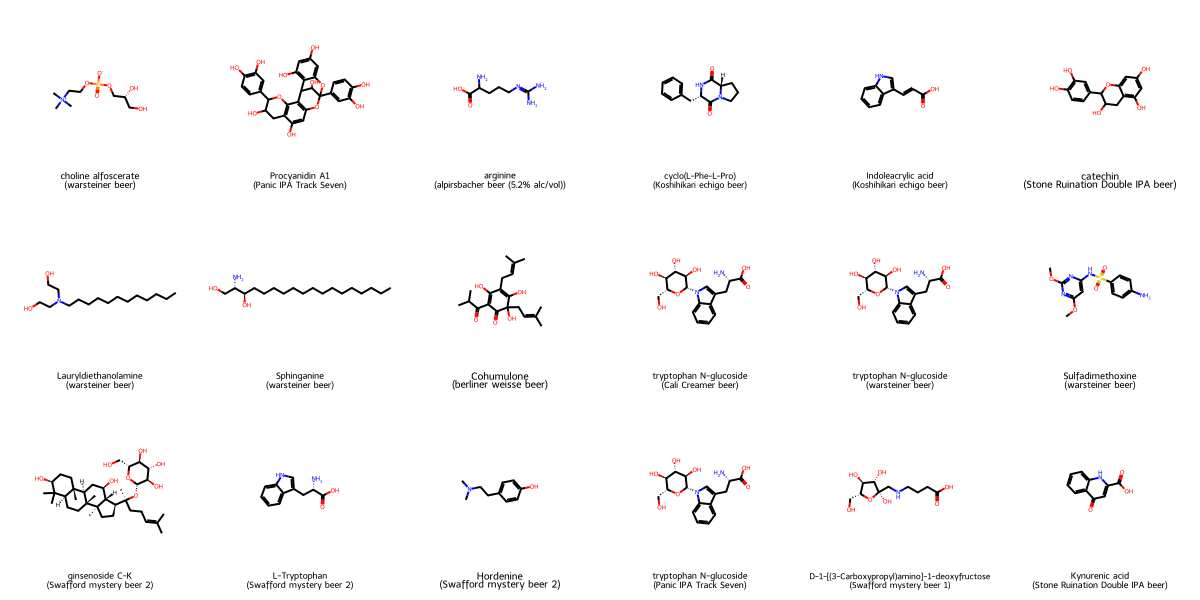

In [ ]:
df_rand_hits = df_search[df_search['ref_name'] != ''].sample(n=18, random_state=7)
show_mols(
    mols=df_rand_hits['ref_smiles'].to_list(),
    legends=[f'{mol_name}\n({beer_name})'
      for mol_name, beer_name
      in zip(df_rand_hits['ref_name'].to_list(), df_rand_hits['description'].to_list())]
)

Let's see the number of molecules retrieved from MassSpecGym for each beer sample.

In [ ]:
mol_names = df_search[df_search['ref_name'] != ''].groupby(by='description').agg({'ref_name': set})
mol_names['ref_name'].apply(len).rename('Num. of molecules annotated')

,Num. of molecules annotated
description,
Cali Creamer beer,28
Koshihikari echigo beer,24
Panic IPA Track Seven,42
Stone Ruination Double IPA beer,41
Swafford mystery beer 1,27
Swafford mystery beer 2,33
alpirsbacher beer (5.2% alc/vol),30
berliner weisse beer,35
gingerbeer,12


### Inspect annotated regions of embedding space

Now that some MS/MS spectra are annotated, we can ask more targeted questions such as "Which compounds (or compound families) can be found in each type of beer?".

✨ Exercise:
- Identify molecules that differentiate `rootbeer` and `berliner weisse beer`.
- Identify molecules that overlap between multiple beers.

In [ ]:
# Hint: if you see error "TypeError: 'NoneType' object cannot be interpreted as an integer", try chaning port in
# the last line (e.g., change port=8753 to port=8754)

# Plot UMAP
df_search['x'] = embs_umap[:, 0]
df_search['y'] = embs_umap[:, 1]
fig = px.scatter(
    df_search,
    x='x',
    y='y',
    color='description',
    width=900,
    height=650,
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(xaxis_title=None, yaxis_title=None,)

# Add MassSpecGym molecule annotations
app = molplotly.add_molecules(
    fig=fig,
    df=df_search,
    smiles_col='ref_smiles',
    title_col='ref_name',
    color_col='description',
    caption_cols=['DreaMS_similarity', 'precursor_mz', 'ref_precursor_mz', 'description']
)
app.run_server(port=8765, height=700, dev_tools_ui=False, dev_tools_props_check=False,)

/usr/local/lib/python3.11/dist-packages/dash/dash.py:556: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



<IPython.core.display.Javascript object>

Dash app running on:
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

#### Tigogenin-related signals in root beer

A distinct cluster of **tigogenin-related molecules** is observed in the **rootbeer** sample set and is largely absent from conventional beers in this dataset. This pattern supports a qualitative chemical distinction between botanical beverages and hop/malt-dominated beers

### IPA-specific molecules

The UMAP view is useful, but it is hard to make exact “present/absent” statements from a scatter plot.  
Instead, let's directly compare sets of annotated molecules.

✨ Exercise:
- Find molecules present in both IPAs (`Stone Ruination Double IPA beer` and `Panic IPA Track Seven`) but absent from all other beers.


Shared only between:
  - Stone Ruination Double IPA beer
  - Panic IPA Track Seven

Number of molecules: 4



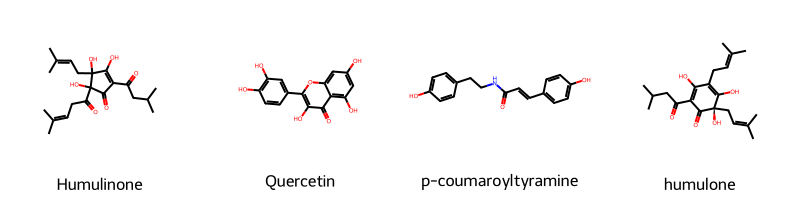

In [ ]:
# Sets of molecules for both IPAs
A_name = "Stone Ruination Double IPA beer"
B_name = "Panic IPA Track Seven"
A = mol_names.loc[A_name, "ref_name"]
B = mol_names.loc[B_name, "ref_name"]

# Union of all molecules from all OTHER beers
others = set().union(*mol_names.drop(index=[A_name, B_name])["ref_name"])

# Molecules present in both A and B, but nowhere else
unique_shared = list((A & B) - others)

print(f"Shared only between:")
print(f"  - {A_name}")
print(f"  - {B_name}")
print(f"\nNumber of molecules: {len(unique_shared)}\n")

show_mols(
    mols=df_search.drop_duplicates(subset=['ref_name']).set_index('ref_name').loc[unique_shared]['ref_smiles'],
    legends=unique_shared,
    mols_per_row=min(6, len(unique_shared))
)

These molecules are predominantly associated with IPA beers, consistent with their high hop load and intensive hopping practices. **Humulone** and **humulinone** are hop-derived bitter acids whose abundance increases with large hop additions and dry hopping, while **quercetin** is a hop-associated flavonoid that typically becomes detectable only at elevated hop concentrations. **p-Coumaroyltyramine** is a plant-derived phenolic amide that has been reported in hops and hop-rich beverages.

In contrast, lagers and lightly hopped styles generally employ substantially lower hop additions or rely on hop extracts, which likely results in absence or reduced concentrations of these compounds. Please note that these molecules may be absent from MS/MS data for these beers not because they are truly absent, but because their lower abundance leads to insufficient MS1 signal intensity to trigger MS/MS acquisition. In this tutorial, we focus on MS/MS data only.

### Beyond individual spectra: whole-beer embeddings

Library matching typically annotates only a minority of MS/MS spectra. If we restrict analysis to annotated molecules, we ignore a large part of the measured chemistry.

To use all MS/MS information, we build a **whole-beer embedding** by averaging DreaMS embeddings across all MS/MS spectra in a sample. This gives a simple, annotation-free representation that often captures meaningful sample-level similarity.  


In [ ]:
# Compute beer embeddings by averaging embeddings of their MS/MS spectra
embs_avg = {k: v.mean(axis=0) for k, v in embs.items()}

### PCA of whole-beer embeddings

To obtain a quick overview of global similarity, we project the beer embeddings into two dimensions using PCA. We use PCA rather than UMAP here because it is better suited to a small number of data points (12 beers in our case).

✨ Exercise:
- Try interpreting the PCA axes.

In [ ]:
# Prepare data for PCA
X = np.array(list(embs_avg.values()))
beer_names = [df.loc[k, "description"] for k in embs_avg.keys()]
X_std = StandardScaler().fit_transform(X)

# Project embeddings into 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

# Plot PCA projection
plot_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "beer": beer_names})
fig = px.scatter(
    plot_df,
    x="PC1",
    y="PC2",
    color="beer",
    hover_name="beer",
)
fig.update_layout(
    width=600,
    height=450,
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)",
)
fig.update_traces(marker=dict(size=12))
fig.update_xaxes(showgrid=True, gridwidth=1)
fig.update_yaxes(showgrid=True, gridwidth=1)
fig.show()

Observations from the PCA plot of beer embeddings:
- Ginger beer and root beer strongly separate from malt-based beers.
- Traditional lagers/wheat beers tend to group more tightly.
- IPAs are close to each other.

PCA is only a partial view. The first two components explain around 60% of variance, so we ingore 40% of the information. Let's try to build a more precise beer taxonomic tree.


### From PCA to a “beer taxonomy”

A dendrogram built from cosine distances between beer embeddings gives a more faithful picture of similarity than a 2D projection.

✨ Exercise:
- Do PCA and taxonomic tree agree?
- Try to interpret clusters and distances in the tree.
- What is teh final verdict for the mystery beers?

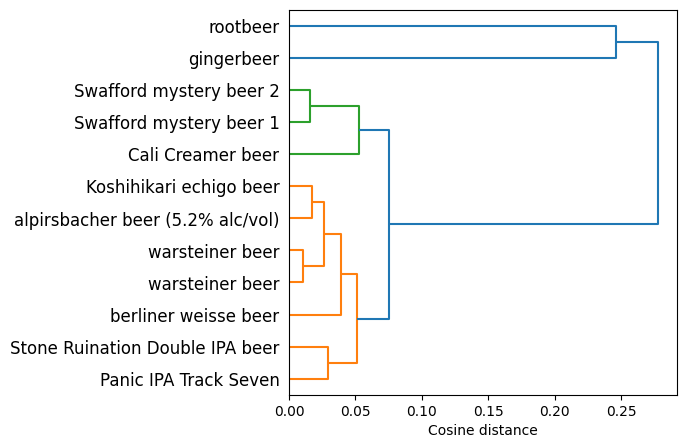

In [ ]:
# Compute pairwise cosine distances
cosine_dist = pdist(np.array(list(X)), metric="cosine")

# Perform hierarchical clustering
Z = linkage(cosine_dist, method="average")  # 'single' linkage selects clusters with the closest (minimum distance) pairs

# Plot dendrogram
plt.figure(figsize=(5, 5))
dendrogram(Z, labels=list(beer_names), orientation="right", color_threshold=0.07)
plt.xlabel("Cosine distance")
plt.show()

You may notice two broad clusters (e.g., a hop/non-hop split or "traditional beer" versus "flavored/other" beverages). Root beer and ginger beer form a clearly distinct branch from the "traditional beers". IPAs also group well within the broader cluster, as expected. However, the distinction between the green and orange clusters is less obvious from beer style alone. The green cluster contains the Swafford mystery beers and the Cali Creamer beer, whereas the orange cluster includes clean lagers (Warsteiner, Koshihikari, Alpirsbacher), Berliner Weisse, and the two IPAs.

This pattern suggests that the green–orange separation may be explained by differences in chemical diversities of beers. Driven by this hypothesis, let's compute within-beer chemical diversity as the standard deviation of spectrum embeddings for each beer.

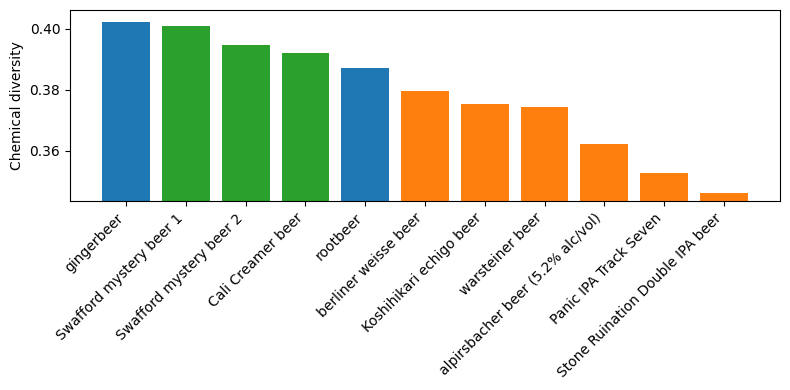

In [ ]:
# Compute chemical diversity scores
chemical_diversities = {df.loc[k, 'description']: v.std() for k, v in embs_avg.items()}

# Plot the scores
div_df = pd.DataFrame({
    "Beer": list(chemical_diversities.keys()),
    "Chemical diversity": list(chemical_diversities.values())
}).sort_values("Chemical diversity", ascending=False)

plt.figure(figsize=(8, 4))

colors = []
green_beers = {"Swafford mystery beer 1", "Swafford mystery beer 2", "Cali Creamer beer",}
blue_beers = {"rootbeer", "gingerbeer"}
for b in div_df["Beer"]:
    if b in green_beers:
        colors.append("C2")
    elif b in blue_beers:
        colors.append("C0")
    else:
        colors.append("C1")

min_val = div_df["Chemical diversity"].min()
plt.bar(div_df["Beer"], div_df["Chemical diversity"], color=colors)
plt.ylim(
    min_val - 0.05 * (div_df["Chemical diversity"].max() - min_val),
    div_df["Chemical diversity"].max() * 1.01
)
plt.ylabel("Chemical diversity")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Indeed, under our definition of chemical diversity, the Swafford mystery beers and the Cali Creamer beer exhibit higher within-beer variability, supporting the hypothesis that the green cluster in dendrogram reflects increased chemical heterogeneity.